# PCA - Exploratory Data Analysis (Practice Notebook)

This is a practice remix of the standard PCA visualization lab, rebuilt with **brand new datasets** so you can
practice the same ideas without just re-running someone else's numbers.

In this notebook you will:

- Replicate the classic "2 nearly-identical features" PCA example, using study-hours vs exam-score data
- Visualize how different projection directions keep different amounts of information from a 2D point cloud, and confirm the best direction matches what `sklearn`'s PCA finds
- Visualize how 3-dimensional data that actually lies on a tilted plane can be fully described in 2 dimensions
- Use PCA to uncover hidden clusters in a high-dimensional synthetic dataset (500 samples, 1000 features)

Everything below is self-contained (no external data files or helper scripts needed) - just run the cells top to bottom.

## 1. Importing the libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (enables 3D projection in matplotlib)
from sklearn.decomposition import PCA
from sklearn.datasets import make_blobs

np.random.seed(42)
%matplotlib inline

## 2. A simple 2-feature example

Let's build a tiny dataset: **hours studied** vs **exam score (out of 100)** for 6 students.
The two features are almost perfectly linearly related - similar in spirit to Andrew's original lecture example,
just with a different story attached to the numbers.

In [2]:
X = np.array([
    [2.0, 52.0],
    [2.5, 55.0],
    [3.0, 58.5],
    [6.0, 78.0],
    [6.5, 81.5],
    [7.0, 84.0],
])
X

array([[ 2. , 52. ],
       [ 2.5, 55. ],
       [ 3. , 58.5],
       [ 6. , 78. ],
       [ 6.5, 81.5],
       [ 7. , 84. ]])

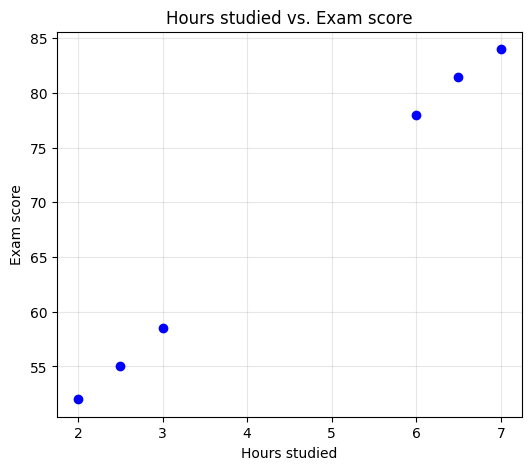

In [3]:
plt.figure(figsize=(6, 5))
plt.plot(X[:, 0], X[:, 1], 'bo')
plt.xlabel('Hours studied')
plt.ylabel('Exam score')
plt.title('Hours studied vs. Exam score')
plt.grid(alpha=0.3)
plt.show()

In [4]:
# Loading the PCA algorithm
pca_2 = PCA(n_components=2)
pca_2

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",2
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

In [5]:
# Let's fit the data. sklearn's PCA implementation already centers the data for us.
pca_2.fit(X)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",2
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

In [6]:
pca_2.explained_variance_ratio_

array([9.99992887e-01, 7.11289337e-06])

Because exam score rises almost linearly with hours studied, the **first principal component alone**
should already capture the vast majority of the variance ("explained variance") in this dataset. The second
component only picks up whatever small amount of noise is left over.

In [7]:
X_trans_2 = pca_2.transform(X)
X_trans_2

array([[-1.63588208e+01, -9.63875700e-03],
       [-1.33176701e+01,  2.78117569e-02],
       [-9.78234770e+00, -1.08579346e-02],
       [ 9.94707162e+00, -1.45154672e-02],
       [ 1.34823940e+01, -5.31851587e-02],
       [ 1.60293730e+01,  6.03855605e-02]])

Think of column 1 as the coordinate along the first principal component (the first new axis), and column 2
as the coordinate along the second principal component (the second new axis).

Given how much variance PC1 retains, we could probably just keep that single component.

In [8]:
pca_1 = PCA(n_components=1)
pca_1

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",1
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

In [9]:
pca_1.fit(X)
pca_1.explained_variance_ratio_

array([0.99999289])

In [10]:
X_trans_1 = pca_1.transform(X)
X_trans_1

array([[-16.35882081],
       [-13.31767013],
       [ -9.7823477 ],
       [  9.94707162],
       [ 13.48239404],
       [ 16.02937298]])

Notice this column is just the first column of `X_trans_2`.

If you have 2 features and choose 2 principal components, you keep *all* the information, and the
reconstructed data should end up (almost) exactly the same as the original.

In [11]:
X_reduced_2 = pca_2.inverse_transform(X_trans_2)
X_reduced_2

array([[ 2. , 52. ],
       [ 2.5, 55. ],
       [ 3. , 58.5],
       [ 6. , 78. ],
       [ 6.5, 81.5],
       [ 7. , 84. ]])

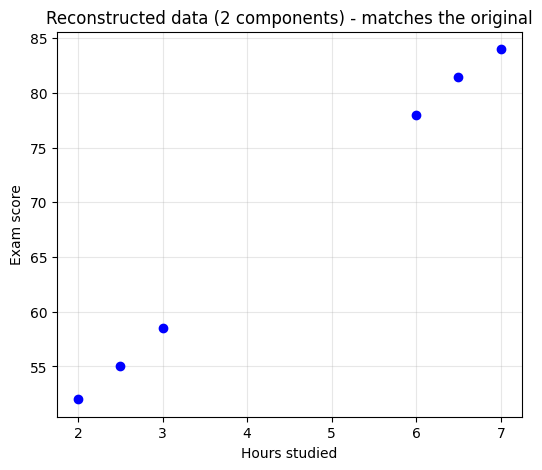

In [12]:
plt.figure(figsize=(6, 5))
plt.plot(X_reduced_2[:, 0], X_reduced_2[:, 1], 'bo')
plt.xlabel('Hours studied')
plt.ylabel('Exam score')
plt.title('Reconstructed data (2 components) - matches the original')
plt.grid(alpha=0.3)
plt.show()

Now let's reduce to 1 dimension instead of 2, and reconstruct from that.

In [13]:
X_reduced_1 = pca_1.inverse_transform(X_trans_1)
X_reduced_1

array([[ 2.0095264 , 51.99853259],
       [ 2.47251243, 55.00423407],
       [ 3.01073137, 58.49834698],
       [ 6.01434627, 77.99779016],
       [ 6.55256521, 81.49190307],
       [ 6.94031832, 84.00919312]])

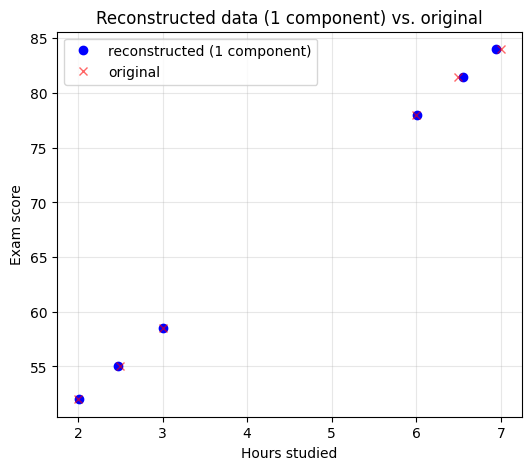

In [14]:
plt.figure(figsize=(6, 5))
plt.plot(X_reduced_1[:, 0], X_reduced_1[:, 1], 'bo', label='reconstructed (1 component)')
plt.plot(X[:, 0], X[:, 1], 'rx', alpha=0.6, label='original')
plt.xlabel('Hours studied')
plt.ylabel('Exam score')
plt.title('Reconstructed data (1 component) vs. original')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Notice how the reconstructed points now all fall on a single straight line - that line **is** the one
principal component that was used to describe the data, and each point just has a single "coordinate" along
that line describing its location.

## 3. Visualizing PCA: not every projection is equally good

Let's place 10 points in the plane and see what happens when we try to compress them onto a single line at
different angles. Some angles keep the points nicely spread apart (retaining a lot of information); others
squash several points almost on top of each other (losing information).

In [15]:
X = np.array([
    [ 1.2,  0.9],
    [ 0.8, -1.1],
    [-1.5,  0.3],
    [-0.9, -0.8],
    [ 1.9,  1.6],
    [ 0.1,  1.8],
    [-1.8, -1.3],
    [ 0.4, -0.2],
    [-0.3,  1.1],
    [ 1.4, -1.6],
])

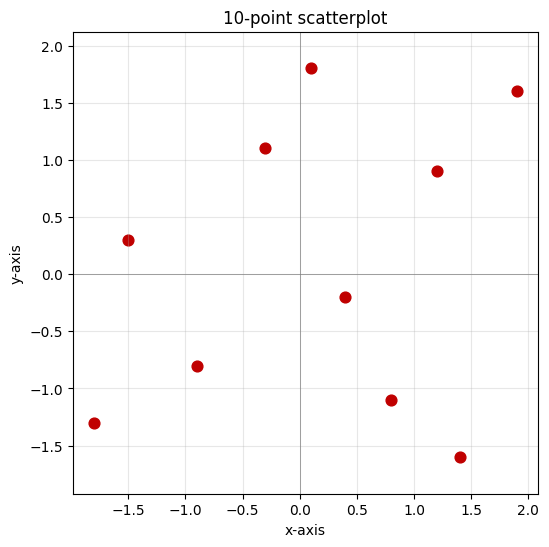

In [16]:
plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], color='#C00000', s=60)
plt.axhline(0, color='gray', lw=0.5)
plt.axvline(0, color='gray', lw=0.5)
plt.title('10-point scatterplot')
plt.xlabel('x-axis')
plt.ylabel('y-axis')
plt.grid(alpha=0.3)
plt.axis('equal')
plt.show()

The function below projects every point onto a line through the origin at a chosen angle, then reports
how much variance (spread) the projected points retain at that angle. Run it for several angles - or, if you
have `ipywidgets` installed, drag the slider to rotate the line yourself and watch the projected points move.

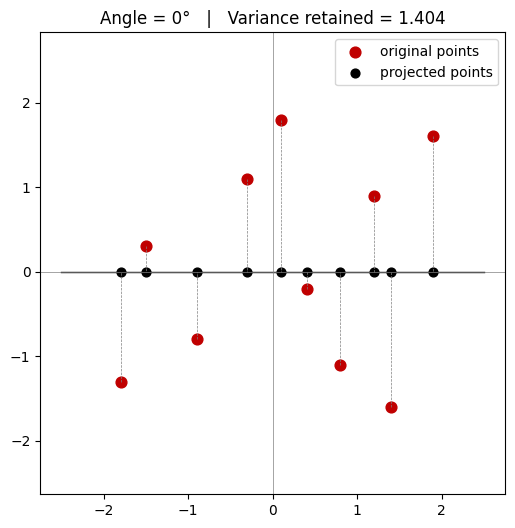

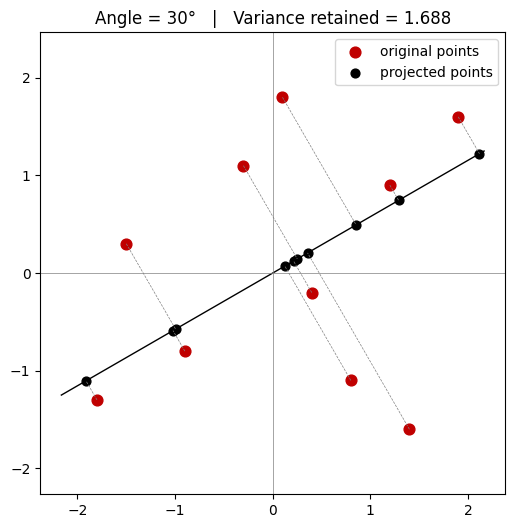

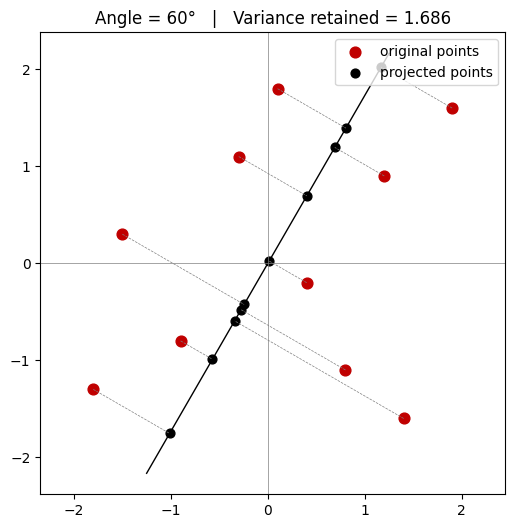

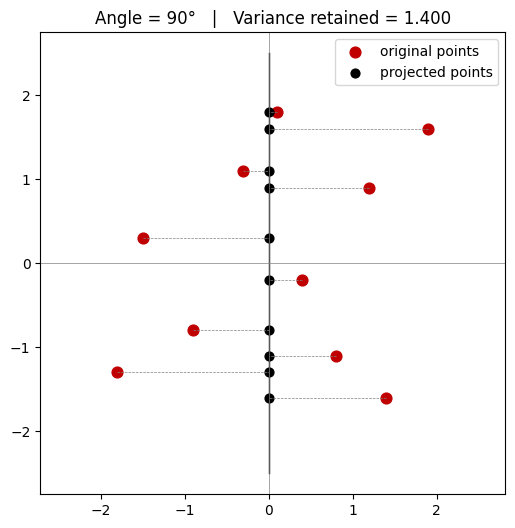

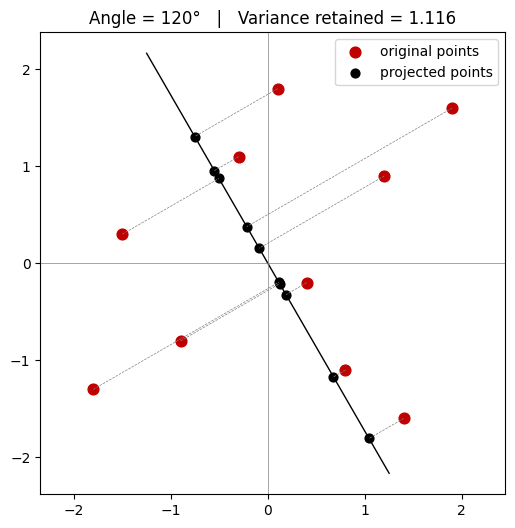

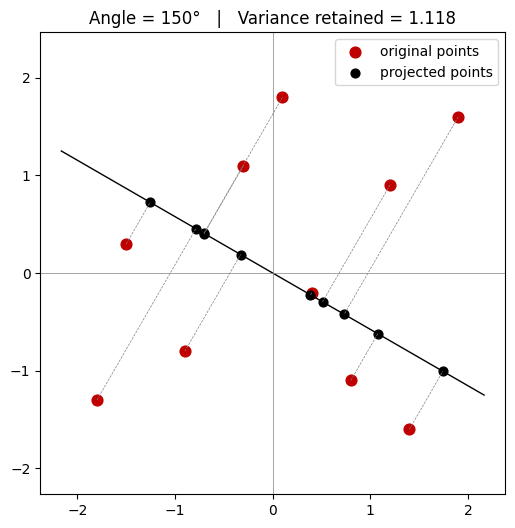

In [17]:
def show_projection(angle_degrees=0):
    theta = np.deg2rad(angle_degrees)
    direction = np.array([np.cos(theta), np.sin(theta)])

    # Project every point onto the line defined by `direction`
    projections_scalar = X @ direction                          # 1D coordinate along the line
    projections_2d = np.outer(projections_scalar, direction)    # back to 2D points on the line

    variance_retained = np.var(projections_scalar)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(X[:, 0], X[:, 1], color='#C00000', s=60, label='original points')
    ax.scatter(projections_2d[:, 0], projections_2d[:, 1], color='black', s=40, label='projected points')

    line_pts = np.array([-2.5 * direction, 2.5 * direction])
    ax.plot(line_pts[:, 0], line_pts[:, 1], 'k-', lw=1)

    for p, q in zip(X, projections_2d):
        ax.plot([p[0], q[0]], [p[1], q[1]], color='gray', lw=0.5, linestyle='--')

    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-2.5, 2.5)
    ax.axhline(0, color='gray', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5)
    ax.set_title(f'Angle = {angle_degrees}\u00b0   |   Variance retained = {variance_retained:.3f}')
    ax.legend(loc='upper right')
    ax.axis('equal')
    plt.show()

# A fixed sweep of angles, so this cell always produces output even without ipywidgets
for angle in [0, 30, 60, 90, 120, 150]:
    show_projection(angle)

In [18]:
# Optional: interactive slider version (needs the ipywidgets package).
# If ipywidgets isn't installed in your environment, just skip this cell.
try:
    from ipywidgets import interact, FloatSlider
    interact(show_projection, angle_degrees=FloatSlider(min=0, max=180, step=1, value=0))
except ImportError:
    print("ipywidgets not installed - skipping the interactive slider. "
          "Install it with `pip install ipywidgets` to try it out.")

interactive(children=(FloatSlider(value=0.0, description='angle_degrees', max=180.0, step=1.0), Output()), _do…

The angle where the retained variance is highest is exactly the direction PCA picks as the first
principal component. Let's confirm that with `sklearn`:

In [19]:
pca = PCA(n_components=2)
pca.fit(X)

pc1_angle = np.rad2deg(np.arctan2(pca.components_[0, 1], pca.components_[0, 0])) % 180

print("Principal component directions (rows):")
print(pca.components_)
print("\nAngle of PC1 (degrees, mod 180):", pc1_angle)
print("Explained variance ratio:", pca.explained_variance_ratio_)

Principal component directions (rows):
[[ 0.7092534   0.70495363]
 [-0.70495363  0.7092534 ]]

Angle of PC1 (degrees, mod 180): 44.82579789200627
Explained variance ratio: [0.61729052 0.38270948]


## 4. Visualizing a 3D dataset that is really 2D

Let's generate 3D points that lie almost exactly on a tilted plane in 3D space (plus a little noise), then see
how PCA finds that plane and lets us describe every point with just 2 coordinates instead of 3.

In [20]:
n_points = 150
u = np.random.uniform(-2, 2, n_points)
v = np.random.uniform(-2, 2, n_points)

# Define a tilted plane in 3D: z depends on x and y, plus a small amount of noise
a, b = 0.6, -0.4
x = u
y = v
z = a * u + b * v + np.random.normal(0, 0.05, n_points)

X_3d = np.column_stack([x, y, z])
X_3d[:5]

array([[-0.50183952,  1.63306354, -0.95205054],
       [ 1.80285723, -1.04175244,  1.46583529],
       [ 0.92797577, -1.42042051,  1.23215087],
       [ 0.39463394, -0.04218896,  0.2853519 ],
       [-1.37592544,  1.94260182, -1.70385312]])

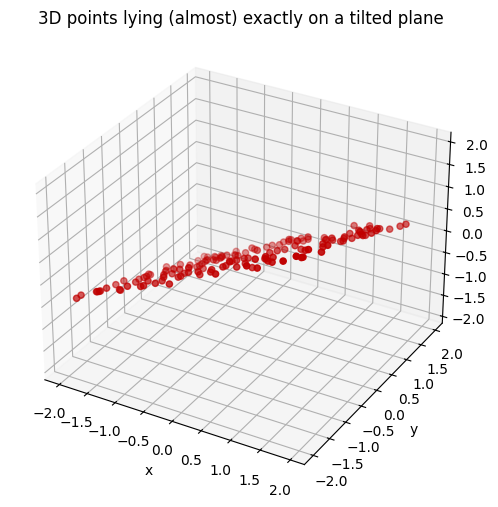

In [21]:
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2], color='#C00000', s=20)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title('3D points lying (almost) exactly on a tilted plane')
plt.show()

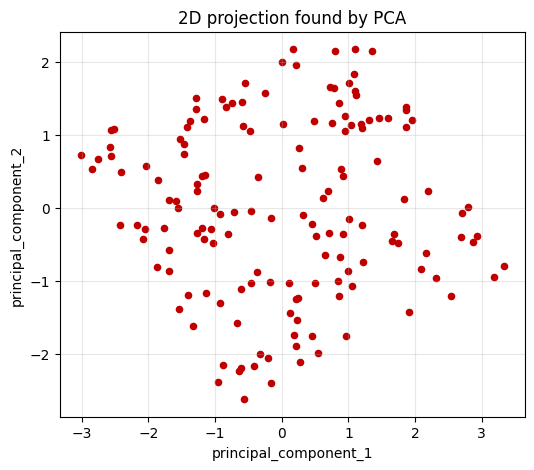

Explained variance ratio: [0.59252231 0.40707559]
Total variance kept with 2 components: 0.999597896839644


In [22]:
pca_3to2 = PCA(n_components=2)
X_3d_pca = pca_3to2.fit_transform(X_3d)

plt.figure(figsize=(6, 5))
plt.scatter(X_3d_pca[:, 0], X_3d_pca[:, 1], color='#C00000', s=20)
plt.xlabel('principal_component_1')
plt.ylabel('principal_component_2')
plt.title('2D projection found by PCA')
plt.grid(alpha=0.3)
plt.show()

print("Explained variance ratio:", pca_3to2.explained_variance_ratio_)
print("Total variance kept with 2 components:", sum(pca_3to2.explained_variance_ratio_))

Even though the raw data has 3 coordinates, almost all of the variance is captured with just 2 principal
components - confirming that these points really live on (approximately) a 2D plane inside 3D space.

## 5. Using PCA for Exploratory Data Analysis on high-dimensional data

Let's build a synthetic dataset with **500 samples and 1000 features** that secretly contains several hidden
clusters - the kind of structure you can't easily spot just by staring at the raw numbers or a handful of
pairwise scatter plots.

In [23]:
X_high, y_true = make_blobs(
    n_samples=500,
    n_features=1000,
    centers=9,
    cluster_std=8.0,
    random_state=42,
)

df = pd.DataFrame(X_high, columns=[f'feature_{i}' for i in range(X_high.shape[1])])
df.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_990,feature_991,feature_992,feature_993,feature_994,feature_995,feature_996,feature_997,feature_998,feature_999
0,-6.655929,-0.749666,-10.929135,-6.967756,-2.494169,-10.300806,-9.721139,4.326578,4.400794,-9.984301,...,5.395990,-10.244751,-2.528330,6.131624,-8.906775,-3.369394,-16.700299,3.063275,2.251630,14.015023
1,2.328458,0.704406,5.488857,0.733385,14.845739,-12.885870,7.421803,0.903123,-5.556436,10.925756,...,-18.403789,0.499666,14.966616,-6.060866,-2.260824,-4.849406,-6.026108,4.249927,-11.833623,-19.640427
2,2.810345,2.550411,6.196741,10.627380,17.060423,-0.433321,2.915761,-7.376828,12.361818,-14.790030,...,-2.258153,-8.150498,20.800150,-13.139097,7.175669,-3.576510,-3.321219,-4.626370,-2.497402,2.814244
3,18.381334,-4.252301,1.874779,9.919420,-10.620450,-1.002597,-3.270212,-8.303149,-2.633058,-19.255853,...,-5.432776,-13.571086,-13.301620,-3.378895,14.264182,-2.271071,-6.418652,0.865445,-2.115016,-16.672720
4,12.020873,8.969787,-0.793784,2.139596,3.247605,-1.966948,13.833243,1.535744,-8.745325,-10.455694,...,-0.538974,-8.798852,-5.545460,-20.961387,-15.194608,17.539093,-13.861969,6.583830,-19.382542,2.791563


This is a dataset with 1000 features. The following function randomly samples pairs of features so we
can scatter-plot them and look for any obvious pattern.

In [24]:
from random import randint, seed
seed(1)

def get_pairs(n=25):
    tuples = []
    while len(tuples) < n:
        x = df.columns[randint(0, df.shape[1] - 1)]
        y = df.columns[randint(0, df.shape[1] - 1)]
        if x != y and (x, y) not in tuples and (y, x) not in tuples:
            tuples.append((x, y))
    return tuples

pairs = get_pairs(25)

Now let's plot them.

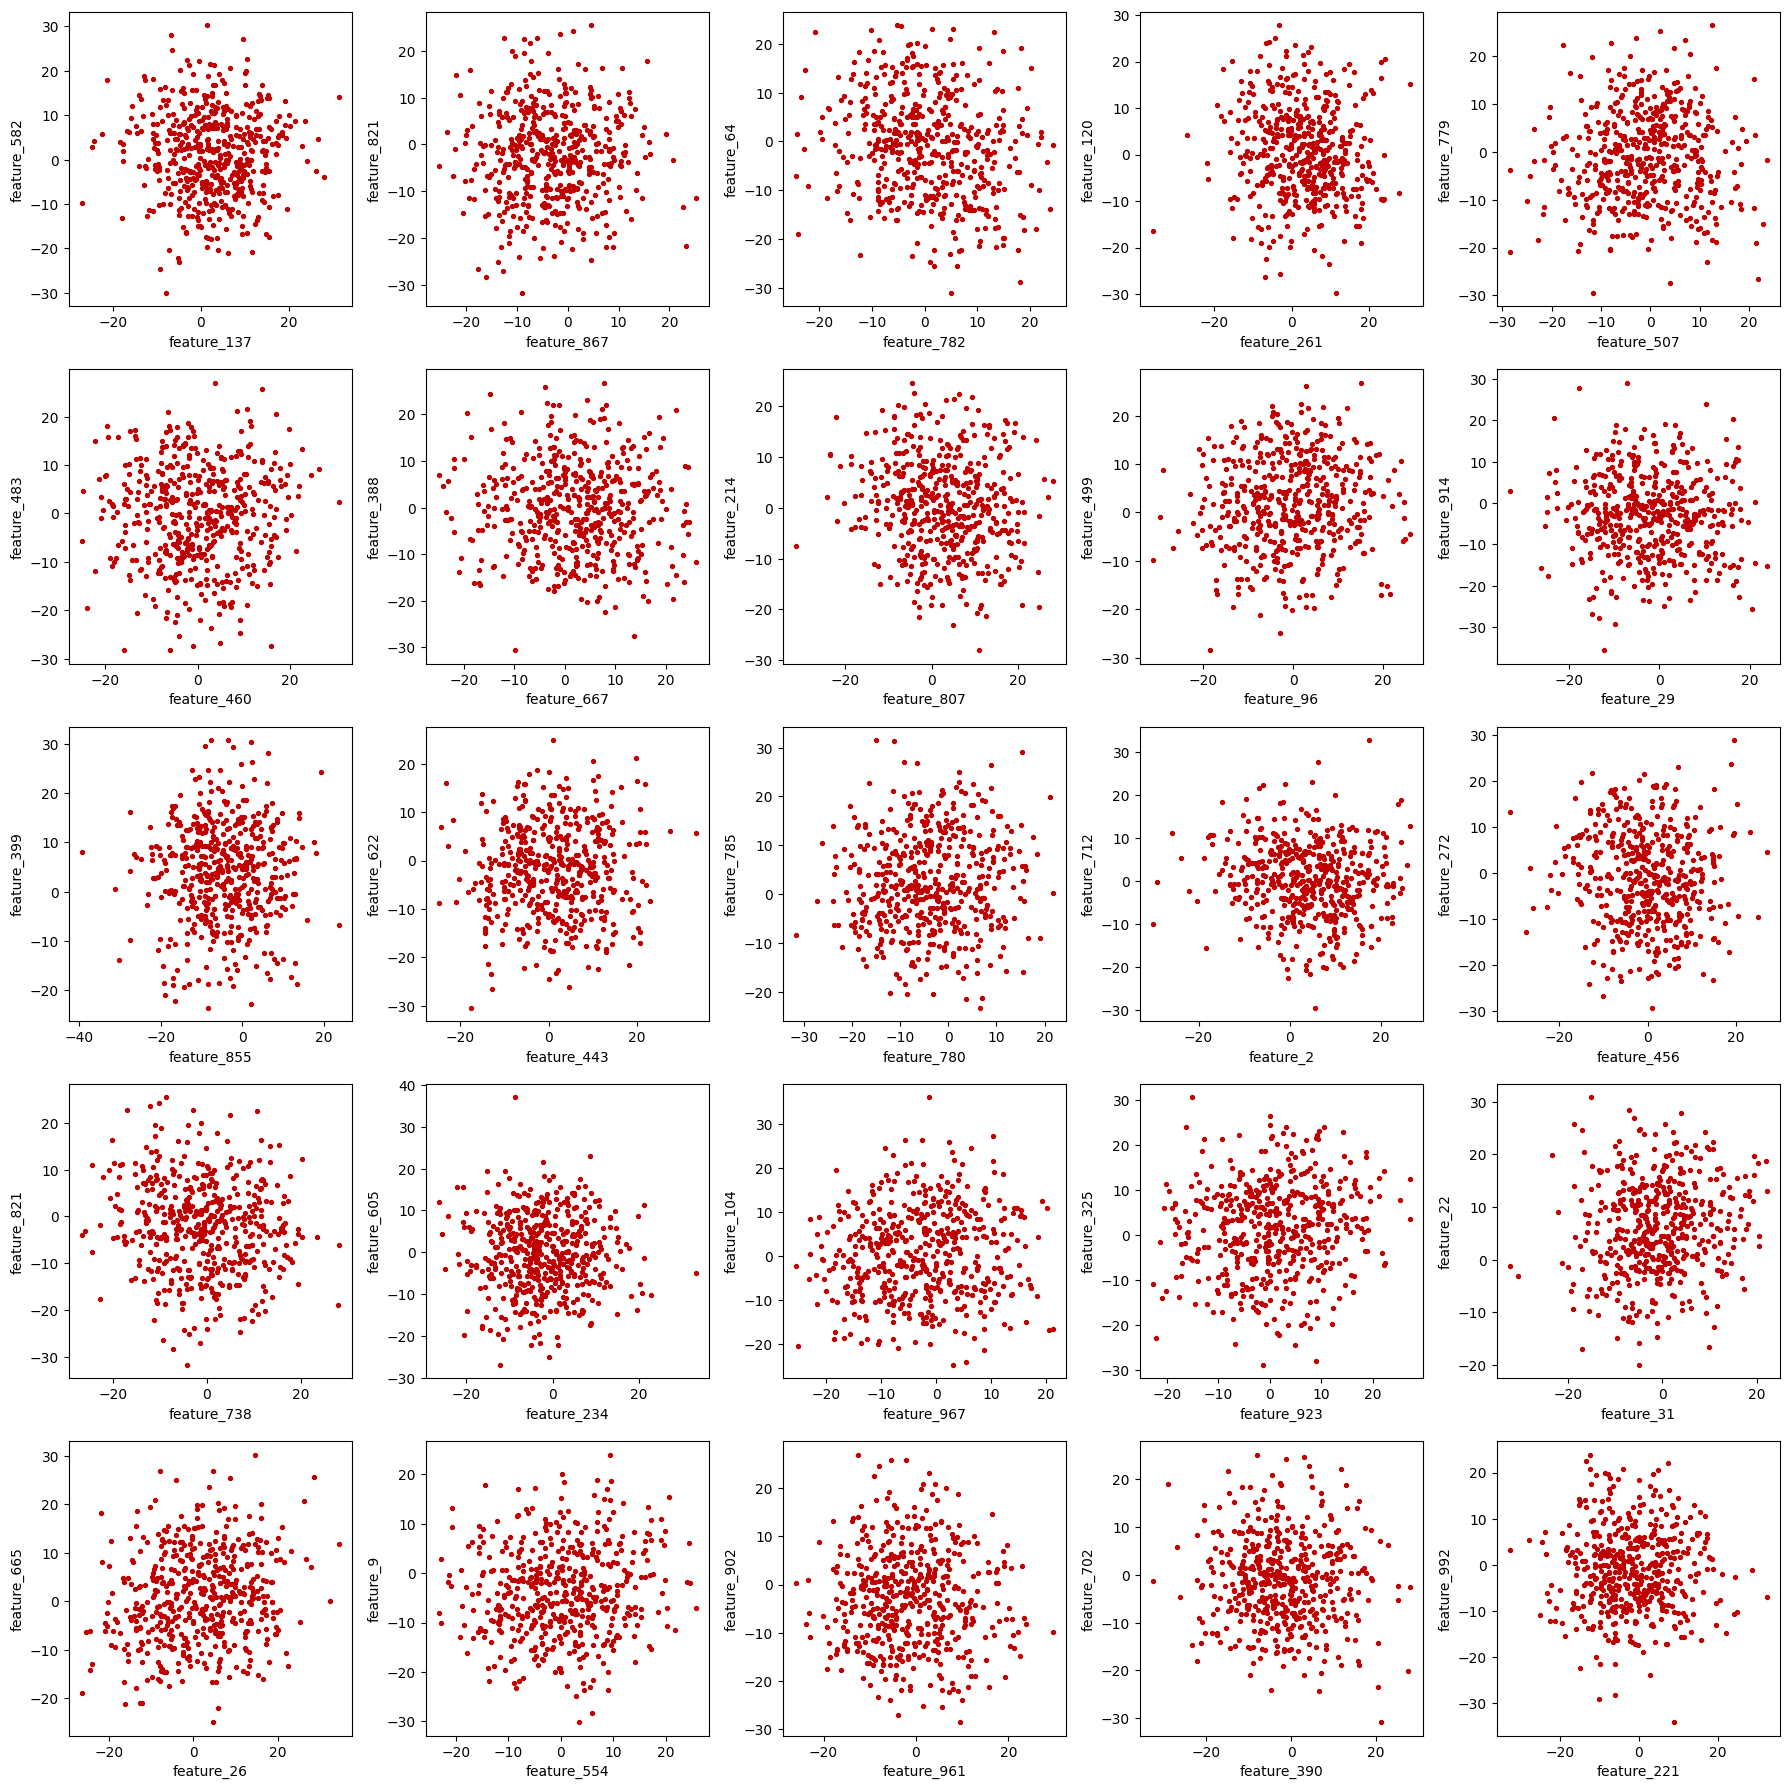

In [25]:
fig, axs = plt.subplots(5, 5, figsize=(18, 18))
i = 0
for row in axs:
    for ax in row:
        ax.scatter(df[pairs[i][0]], df[pairs[i][1]], color="#C00000", s=8)
        ax.set_xlabel(pairs[i][0])
        ax.set_ylabel(pairs[i][1])
        i += 1
plt.tight_layout()
plt.show()

It looks like there is not much information hidden in random pairs of features, and it's not practical
to check every combination out of 1000 features. Let's look at linear correlation instead.

In [26]:
# This may take a little while with 1000 features
corr = df.corr()

# Show all feature pairs with correlation > 0.3 in absolute value (excluding a feature's correlation with itself)
mask = (abs(corr) > 0.3) & (abs(corr) != 1)
corr.where(mask).stack().sort_values()

feature_294  feature_535   -0.491364
feature_535  feature_294   -0.491364
feature_470  feature_731   -0.480815
feature_731  feature_470   -0.480815
feature_300  feature_182   -0.468385
                              ...   
feature_999  feature_995         NaN
             feature_996         NaN
             feature_997         NaN
             feature_998         NaN
             feature_999         NaN
Length: 1000000, dtype: float64

The correlations between individual features are all pretty weak - nothing obviously stands out.

Let's try PCA to compress the 1000 features into a 2-dimensional plane we can plot as a scatter plot.

In [27]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df)
df_pca = pd.DataFrame(X_pca, columns=['principal_component_1', 'principal_component_2'])
df_pca.head()

,principal_component_1,principal_component_2
0,-63.858972,12.406556
1,110.120476,-6.050159
2,79.836643,-84.708209
3,10.039217,77.492415
4,12.947013,-49.601704


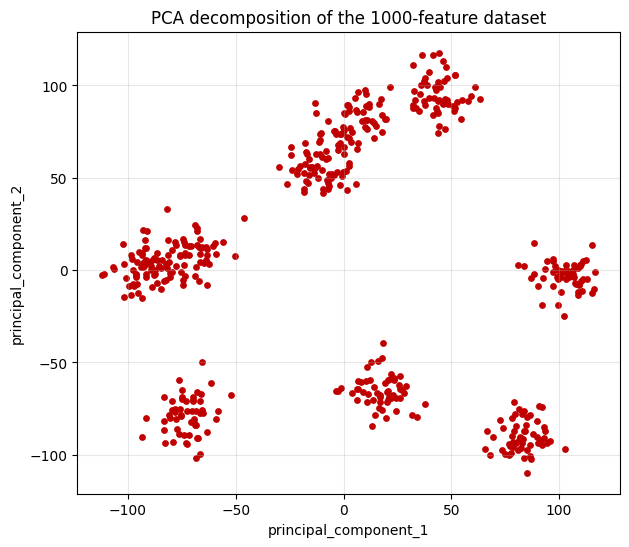

In [28]:
plt.figure(figsize=(7, 6))
plt.scatter(df_pca['principal_component_1'], df_pca['principal_component_2'], color="#C00000", s=15)
plt.xlabel('principal_component_1')
plt.ylabel('principal_component_2')
plt.title('PCA decomposition of the 1000-feature dataset')
plt.grid(alpha=0.3)
plt.show()

Well-defined clusters suddenly appear, even though we couldn't spot them in the raw pairwise scatter plots!

In [29]:
sum(pca.explained_variance_ratio_)

np.float64(0.09176931265305655)

Just 2 out of 1000 original dimensions are enough to reveal the underlying group structure - even
though those two components only capture a modest slice of the total variance. Let's add a third component for
an even clearer separation.

In [30]:
pca_3 = PCA(n_components=3)
X_pca_3 = pca_3.fit_transform(df)
df_pca_3 = pd.DataFrame(X_pca_3, columns=['principal_component_1', 'principal_component_2', 'principal_component_3'])

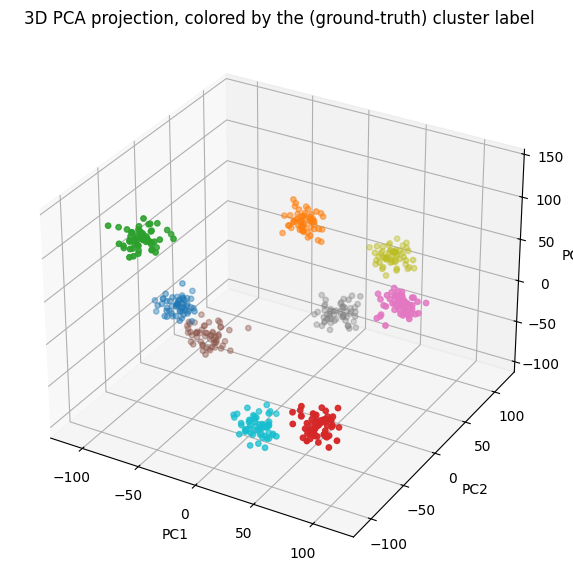

Total variance kept with 3 components: 0.13533527485365365


In [31]:
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(
    df_pca_3['principal_component_1'],
    df_pca_3['principal_component_2'],
    df_pca_3['principal_component_3'],
    c=y_true, cmap='tab10', s=15,
)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('3D PCA projection, colored by the (ground-truth) cluster label')
plt.show()

print("Total variance kept with 3 components:", sum(pca_3.explained_variance_ratio_))

We colored the points above by `y_true` - the cluster label `make_blobs` used when generating the data.
In a real project you normally *wouldn't* have this label; we only have it here because we created the
synthetic data ourselves. It's a nice way to sanity-check that the clusters PCA reveals visually really do
correspond to genuinely different groups in the data, not just a visual illusion.

## Recap

- PCA finds the axes ("principal components") that capture the most variance (spread) in the data.
- The first principal component is the single best 1D summary of higher-dimensional data.
- Data that looks like it needs 3+ dimensions can sometimes be fully described with far fewer, if it lies close
  to a lower-dimensional plane or line.
- PCA is a great first step for exploratory data analysis on high-dimensional data, since it can reveal group
  structure that is invisible in the raw feature space.

Try tweaking `cluster_std`, `centers`, or the noise levels above and re-running the notebook to see how the
PCA plots change.

Congratulations on finishing this practice notebook!